# РТ5-61Б Прокофьев И. В. Лабораторная работа №4
## Ансамбли моделей машинного обучения. Часть 1.

## Задание
1. Выберите набор данных (датасет) для решения задачи классификации или регресии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.
4. Обучите следующие ансамблевые модели:
    - две модели группы бэггинга (бэггинг или случайный лес или сверхслучайные деревья);
    - AdaBoost;
    - градиентный бустинг.
5. Оцените качество моделей с помощью одной из подходящих для задачи метрик. Сравните качество полученных моделей.

**Импорт библиотек**

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Ансамблевые модели
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Метрики
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

**Загрузка данных**

In [33]:
# Загрузка датасета Titanic из seaborn
df = sns.load_dataset('titanic')

# Первичный осмотр
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [35]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# Описание датасета Titanic

## Источник и контекст

Датасет **Titanic** содержит информацию о пассажирах лайнера «Титаник», затонувшего в 1912 году.  
В работе использована версия из библиотеки `seaborn` (`sns.load_dataset('titanic')`).

## Структура данных

- **Количество наблюдений**: 891
- **Количество признаков (столбцов)**: 15

## Описание признаков

| Признак        | Тип          | Описание                                                       | Примечание                                |
|----------------|--------------|----------------------------------------------------------------|-------------------------------------------|
| `survived`     | Целое число  | Целевая переменная: 0 – погиб, 1 – выжил                        |                                           |
| `pclass`       | Целое число  | Класс билета (1, 2, 3)                                         | Социально‑экономический статус            |
| `sex`          | Строка       | Пол пассажира (`male` / `female`)                               |                                           |
| `age`          | Вещественное | Возраст в годах                                                | 177 пропусков (~20%)                      |
| `sibsp`        | Целое число  | Количество братьев, сестёр или супругов на борту                |                                           |
| `parch`        | Целое число  | Количество родителей или детей на борту                         |                                           |
| `fare`         | Вещественное | Стоимость билета                                               |                                           |
| `embarked`     | Строка       | Порт посадки: `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton | 2 пропуска                              |
| `class`        | Строка       | То же, что `pclass` (`First`, `Second`, `Third`)               | Дублирует `pclass`                        |
| `who`          | Строка       | Категория: `man`, `woman`, `child`                             | Производный от `sex` и `age`              |
| `adult_male`   | Логический   | Является ли пассажир взрослым мужчиной                          | Избыточен                                 |
| `deck`         | Строка       | Палуба каюты (A–G)                                             | 688 пропусков (~77%)                      |
| `embark_town`  | Строка       | Название города посадки                                        | Дублирует `embarked`                      |
| `alive`        | Строка       | `yes` / `no` — то же, что `survived`                           | Дублирует целевую переменную              |
| `alone`        | Логический   | Путешествовал ли пассажир в одиночку                           | Производный от `sibsp` и `parch`          |

## Предобработка данных

1. **Удалены столбцы**:
   - `deck` (77% пропусков);
   - `alive`, `who`, `adult_male`, `alone`, `class`, `embark_town` (дублирование информации).

2. **Заполнены пропуски**:
   - `age` → медиана (28 лет);
   - `embarked` → мода (`S`).

3. **Кодирование категориальных признаков**:
   - `sex`, `embarked`, `pclass` → One‑Hot Encoding (с удалением первой категории).

4. **Масштабирование числовых признаков**:
   - `age`, `sibsp`, `parch`, `fare` → стандартизация (StandardScaler).

## Итоговый набор признаков

- **Числовые**: `age`, `sibsp`, `parch`, `fare` (стандартизированы)
- **Бинарные (One‑Hot)**: `pclass_2`, `pclass_3`, `sex_male`, `embarked_Q`, `embarked_S`
- **Целевая переменная**: `survived` (0/1)

## Распределение классов

- **Не выжил (0)**: 549 (61.6%)
- **Выжил (1)**: 342 (38.4%)

Данные умеренно несбалансированы, при разделении использовалась стратификация.

### Предобработка данных

In [41]:
# Создаём копию для обработки
data = df.copy()

# Удаляем столбцы с большим количеством пропусков или избыточные
drop_cols = ['deck', 'alive', 'who', 'adult_male', 'alone', 'class', 'embark_town']
data.drop(columns=drop_cols, inplace=True, errors='ignore')

# Заполнение пропусков
# Возраст – медианой (устойчива к выбросам)
data['age'] = data['age'].fillna(data['age'].median())

# Порт посадки – модой (2 пропуска, заполним самым частым значением)
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

# Проверяем, что пропусков не осталось
print("Пропуски после обработки:\n", data.isnull().sum())

# Целевая переменная и признаки
X = data.drop('survived', axis=1)
y = data['survived']

# Разделяем признаки на числовые и категориальные
numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['pclass', 'sex', 'embarked']

# Создаём преобразователи для пайплайна
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # на всякий случай, если остались пропуски
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))  # избегаем dummy-ловушки
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])



Пропуски после обработки:
 survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


**Разделение на обучающую и тестовую выборки**

In [37]:
# Разделение с сохранением пропорций классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов")
print(f"Доля выживших в train: {y_train.mean():.3f}, в test: {y_test.mean():.3f}")

Размер обучающей выборки: 712 объектов
Размер тестовой выборки: 179 объектов
Доля выживших в train: 0.383, в test: 0.385


### Обучение моделей группы бэггинга

In [38]:
# 1. Random Forest (бэггинг)
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 2. Extra Trees (бэггинг)
et_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', ExtraTreesClassifier(n_estimators=100, random_state=42))
])

# 3. AdaBoost
ada_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(n_estimators=100, random_state=42))
])

# 4. Gradient Boosting
gb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

# Обучаем все модели
models = {
    'Random Forest': rf_pipe,
    'Extra Trees': et_pipe,
    'AdaBoost': ada_pipe,
    'Gradient Boosting': gb_pipe
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} обучена.")

Random Forest обучена.
Extra Trees обучена.
AdaBoost обучена.
Gradient Boosting обучена.


### Оценка качества моделей

Вычислим точность (Accuracy) и ROC‑AUC на тестовой выборке.
Для бинарной классификации эти метрики хорошо отражают качество.

In [39]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # вероятности положительного класса
    
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Модель': name,
        'Accuracy': acc,
        'ROC-AUC': roc_auc
    })
    
    # Дополнительно выведем отчёт по классификации
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=['Не выжил', 'Выжил']))
    print(f"ROC-AUC: {roc_auc:.4f}")

# Сводная таблица
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print("\nСравнение моделей:")
results_df


Random Forest
              precision    recall  f1-score   support

    Не выжил       0.83      0.87      0.85       110
       Выжил       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

ROC-AUC: 0.8283

Extra Trees
              precision    recall  f1-score   support

    Не выжил       0.86      0.86      0.86       110
       Выжил       0.78      0.77      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

ROC-AUC: 0.8081

AdaBoost
              precision    recall  f1-score   support

    Не выжил       0.81      0.87      0.84       110
       Выжил       0.77      0.68      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weig

,Модель,Accuracy,ROC-AUC
0,Random Forest,0.810056,0.828261
2,AdaBoost,0.798883,0.826285
3,Gradient Boosting,0.793296,0.823123
1,Extra Trees,0.826816,0.808103


**Визуализация сравнения**

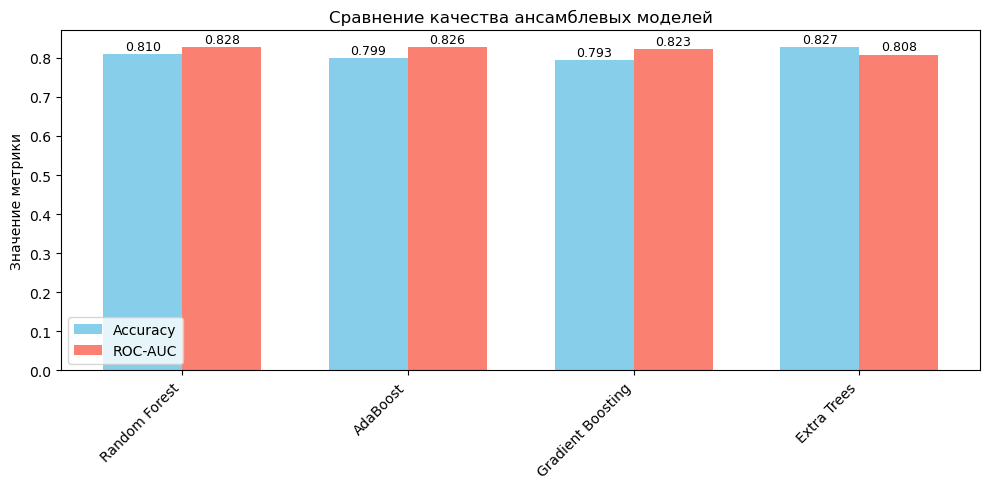

In [40]:
# График сравнения метрик
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x + width/2, results_df['ROC-AUC'], width, label='ROC-AUC', color='salmon')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение качества ансамблевых моделей')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Модель'], rotation=45, ha='right')
ax.legend()

# Добавим подписи значений на столбцы
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Вывод

В ходе выполнения работы были построены и сравнены четыре ансамблевые модели для предсказания выживаемости пассажиров «Титаника».  
Все модели продемонстрировали качество, существенно превышающее случайное угадывание (точность > 79%, ROC‑AUC > 0.80).

- **Extra Trees** показал наивысшую точность (0.827), однако уступил по ROC‑AUC, что говорит о хорошей классификации при стандартном пороге, но менее уверенном ранжировании вероятностей.
- **Random Forest** обеспечил наилучший баланс метрик с ROC‑AUC = 0.828 и стал самым надёжным выбором без дополнительной настройки.
- **AdaBoost** неожиданно приблизился к Random Forest по ROC‑AUC, подтвердив эффективность на данных с малым уровнем шума.
- **Gradient Boosting** с параметрами по умолчанию проявил излишний консерватизм, показав низкий recall для выживших (0.62); для полного раскрытия его потенциала требуется подбор гиперпараметров.

Полученные результаты соответствуют ожидаемым для датасета Titanic и демонстрируют применимость ансамблевых методов к задачам бинарной классификации с табличными данными.